In [1]:
import pandas as pd

# Load BTC CSV
bnb_df = pd.read_csv(r'feature_datasets\BNB_features.csv', parse_dates=True, index_col=0)

# Define X and y
bnb_y = bnb_df['Close'].shift(-1)          # next-day close price
bnb_X = bnb_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
bnb_X = bnb_X.iloc[:-1]
bnb_y = bnb_y.iloc[:-1]

# Optional: check shapes
print("BNB X shape:", bnb_X.shape)
print("BNB y shape:", bnb_y.shape)

BNB X shape: (915, 29)
BNB y shape: (915,)


## 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(bnb_X) * 0.7)

bnb_X_train = bnb_X.iloc[:split_idx].values
bnb_X_test  = bnb_X.iloc[split_idx:].values

bnb_y_train = bnb_y.iloc[:split_idx].values
bnb_y_test  = bnb_y.iloc[split_idx:].values

# Optional: check shapes
print("BNB X_train shape:", bnb_X_train.shape)
print("BNB X_test shape:", bnb_X_test.shape)
print("BNB y_train shape:", bnb_y_train.shape)
print("BNB y_test shape:", bnb_y_test.shape)

BNB X_train shape: (640, 29)
BNB X_test shape: (275, 29)
BNB y_train shape: (640,)
BNB y_test shape: (275,)


In [3]:
bnb_test_dates = bnb_df.index[-len(bnb_X_test):]  # get the dates for test set

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
bnb_X_train_scaled = scaler.fit_transform(bnb_X_train)

# Transform TEST using the same scaler
bnb_X_test_scaled = scaler.transform(bnb_X_test)

# Check shapes
print("Scaled X_train shape:", bnb_X_train_scaled.shape)
print("Scaled X_test shape:", bnb_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [6]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
bnb_y_train_scaled = y_scaler.fit_transform(bnb_y_train.reshape(-1,1)).flatten()

# Scale test target
bnb_y_test_scaled = y_scaler.transform(bnb_y_test.reshape(-1,1)).flatten()

In [7]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BNB using scaled target
bnb_X_train_seq, bnb_y_train_seq = create_sequences(bnb_X_train_scaled, bnb_y_train_scaled, time_steps=30)
bnb_X_test_seq, bnb_y_test_seq = create_sequences(bnb_X_test_scaled, bnb_y_test_scaled, time_steps=30)

# Check shapes
print("BNB X_train_seq shape:", bnb_X_train_seq.shape)
print("BNB y_train_seq shape:", bnb_y_train_seq.shape)
print("BNB X_test_seq shape:", bnb_X_test_seq.shape)
print("BNB y_test_seq shape:", bnb_y_test_seq.shape)

BNB X_train_seq shape: (610, 30, 29)
BNB y_train_seq shape: (610,)
BNB X_test_seq shape: (245, 30, 29)
BNB y_test_seq shape: (245,)


### Training the model

In [8]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [9]:
# Get number of features from the sequences
input_size = bnb_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [10]:
model = train_model(
    model,
    bnb_X_train_seq,
    bnb_y_train_seq,
    epochs=50,       # you can adjust later
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.006749
Epoch [20/50], Loss: 0.004915
Epoch [30/50], Loss: 0.002869
Epoch [40/50], Loss: 0.001475
Epoch [50/50], Loss: 0.003687


In [11]:
bnb_preds = predict_model(model, bnb_X_test_seq)

# Optional: check
print("Predictions shape:", bnb_preds.shape)
print("First 10 predictions:", bnb_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.2989891 ]
 [0.30756342]
 [0.30130285]
 [0.29333922]
 [0.284208  ]
 [0.27989733]
 [0.2750317 ]
 [0.27467343]
 [0.2692957 ]
 [0.26017362]]


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
bnb_y_test_actual = bnb_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(bnb_y_test_actual, bnb_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(bnb_y_test_actual, bnb_preds_actual)
r2 = r2_score(bnb_y_test_actual, bnb_preds_actual)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MSE: 196.92
RMSE: 14.03
MAE: 11.82
R2 Score: 0.8236


In [13]:
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds.reshape(-1,1))

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = bnb_df.index[-len(bnb_X_test):][30:]  # test dates aligned with sequences
actual_seq = bnb_y_test[30:]                      # actual prices aligned
pred_seq = bnb_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,321.952698,333.762360
2023-05-03,326.212891,337.683136
2023-05-04,323.917145,334.820343
2023-05-05,326.940308,331.178833
2023-05-06,322.774017,327.003357
...,...,...
2023-12-28,323.598999,284.191864
2023-12-29,313.878754,298.519897
2023-12-30,317.166199,305.108093


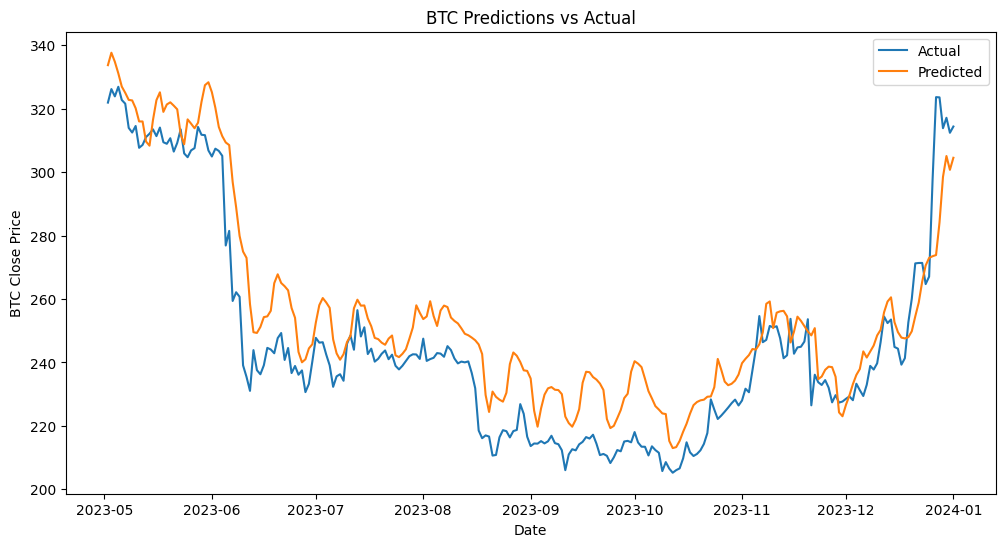

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()